# Flight Delay Prediction

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [75]:
df_raw = pd.read_csv('airline_delay_data.csv')
print(f'Shape : {df_raw.shape}')
print()
df_raw.head(25)

Shape : (1530, 25)



,flight_id,flight_number,date,month,day_of_week,is_weekend,airline,aircraft_type,origin,destination,...,load_factor_pct,weather_origin,weather_dest,origin_congestion,dest_congestion,atc_delay_min,late_aircraft_min,tech_issue_delay_min,dep_delay_min,arr_delay_min
0,FL0430,I5797,2023-06-07,6,Wednesday,0,AirAsia India,A319,JAI,BHO,...,80.0,9.0,10.0,4,2,0.0,0.0,0.0,31.0,77.4
1,FL0330,6E841,2023-01-17,1,Tuesday,0,IndiGo,A320,PAT,BOM,...,87.2,9.0,8.0,2,9,4.1,22.9,0.0,59.6,111.7
2,FL0061,6E101,2023-03-22,3,Wednesday,0,IndiGo,B737,PAT,VTZ,...,83.8,1.0,6.0,2,2,17.3,0.0,0.0,16.0,44.9
3,FL0848,UK956,2023-11-22,11,Wednesday,0,Vistara,A320,CCU,BLR,...,73.1,1.0,4.0,5,7,6.9,0.0,0.0,6.5,32.3
4,FL1448,6E811,2023-05-23,5,Tuesday,0,IndiGo,B737,ATQ,BHO,...,71.9,5.0,7.0,2,2,NaN,27.0,0.0,42.1,55.8
5,FL0726,SG818,2023-08-12,8,Saturday,1,SpiceJet,CRJ-900,JAI,BOM,...,89.9,7.0,6.0,4,9,3.1,10.9,0.0,40.5,116.9
6,FL1163,SG901,2023-07-01,7,Saturday,1,SpiceJet,B737,BHO,ATQ,...,78.1,6.0,7.0,2,2,10.7,0.0,0.0,23.3,77.8
7,FL0596,6E638,2023-08-09,8,Wednesday,0,IndiGo,B737,IXB,GAU,...,71.8,4.0,8.0,2,2,1.4,29.4,0.0,41.4,82.1
8,FL0222,G8505,2023-11-20,11,Monday,0,GoFirst,A320,PNQ,ATQ,...,76.8,6.0,5.0,4,2,2.6,0.0,0.0,9.4,29.1
9,FL0479,6E681,2023-10-16,10,Monday,0,IndiGo,A321,DEL,VTZ,...,81.1,6.0,2.0,9,2,19.5,0.0,0.0,40.9,25.9


In [76]:
print('Column names and types:')
print(df_raw.dtypes)

Column names and types:
flight_id                   str
flight_number               str
date                        str
month                     int64
day_of_week                 str
is_weekend                int64
airline                     str
aircraft_type               str
origin                      str
destination                 str
distance_km               int64
scheduled_dep_hour        int64
flight_duration_min       int64
seat_capacity             int64
passengers_boarded      float64
load_factor_pct         float64
weather_origin          float64
weather_dest            float64
origin_congestion         int64
dest_congestion           int64
atc_delay_min           float64
late_aircraft_min       float64
tech_issue_delay_min    float64
dep_delay_min           float64
arr_delay_min           float64
dtype: object


In [77]:
# Missing values
missing = df_raw.isnull().sum()
miss_df = pd.DataFrame({'Missing Count': missing})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(f'\n1. Missing values found in {len(miss_df)} columns:')
print(miss_df.to_string())

# Duplicates
dupes = df_raw.duplicated().sum()
print(f'\n2. Duplicate rows : {dupes}')


1. Missing values found in 7 columns:
                    Missing Count
atc_delay_min                  91
load_factor_pct                90
late_aircraft_min              90
weather_origin                 76
weather_dest                   75
passengers_boarded             60
aircraft_type                  46

2. Duplicate rows : 30


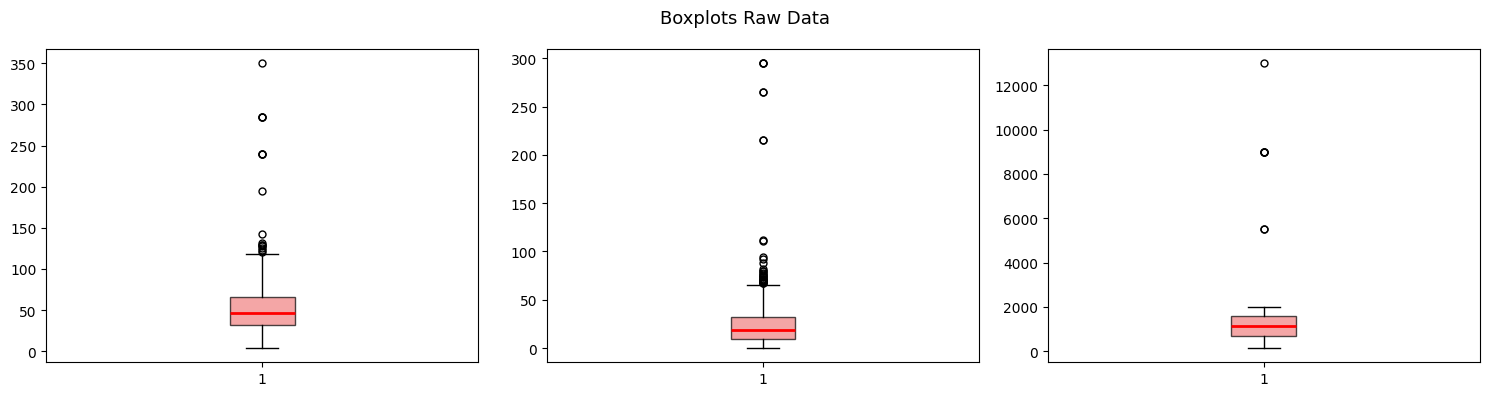

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['arr_delay_min','dep_delay_min','distance_km']):
    data = df_raw[col].dropna()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor='lightcoral', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=5))

plt.suptitle('Boxplots Raw Data', fontsize=13)
plt.tight_layout()
plt.show()

In [79]:
df = df_raw.copy()
before = len(df)
df = df.drop_duplicates()
after  = len(df)
print(f'Rows before : {before}')
print(f'Rows after  : {after}')
print(f'Removed     : {before - after}')

Rows before : 1530
Rows after  : 1500
Removed     : 30


In [80]:
print('Missing values BEFORE filling:')
mv = df.isnull().sum()
print(mv[mv > 0].to_string())
print()

# MEAN imputation

mean_cols = {
    'weather_origin',
    'weather_dest',
    'load_factor_pct',
    'atc_delay_min',
    'late_aircraft_min',
    'passengers_boarded',
}

for col in mean_cols:
    n_null   = df[col].isnull().sum()
    col_mean = df[col].mean()
    df[col]  = df[col].fillna(col_mean)
    print(f'  [MEAN]  {col:<22}  {n_null:>3} nulls filled with mean = {col_mean:.2f}')

print()

# MODE imputation

col      = 'aircraft_type'
n_null   = df[col].isnull().sum()
col_mode = df[col].mode()[0]
df[col]  = df[col].fillna(col_mode)
print(f'  [MODE]  {col:<22}  {n_null:>3} nulls filled with mode = {col_mode}')

print()
print(f'Total missing values after filling : {df.isnull().sum().sum()}')
print()


Missing values BEFORE filling:
aircraft_type         45
passengers_boarded    60
load_factor_pct       90
weather_origin        75
weather_dest          75
atc_delay_min         90
late_aircraft_min     90

  [MEAN]  passengers_boarded       60 nulls filled with mean = 149.95
  [MEAN]  weather_dest             75 nulls filled with mean = 4.59
  [MEAN]  weather_origin           75 nulls filled with mean = 4.62
  [MEAN]  atc_delay_min            90 nulls filled with mean = 5.18
  [MEAN]  load_factor_pct          90 nulls filled with mean = 82.26
  [MEAN]  late_aircraft_min        90 nulls filled with mean = 4.01

  [MODE]  aircraft_type            45 nulls filled with mode = A320

Total missing values after filling : 0



In [81]:
before = len(df)

# Remove outliers from key numeric columns
for col in ['arr_delay_min', 'dep_delay_min', 'distance_km']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    removed = df[(df[col] < lo) | (df[col] > hi)].shape[0]
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f'{col:<22}: {removed} outliers')

df = df.reset_index(drop=True)
print(f'\nRows before outlier removal : {before}')
print(f'Rows after  outlier removal : {len(df)}')
print(f'Total removed               : {before - len(df)}')

arr_delay_min         : 17 outliers
dep_delay_min         : 33 outliers
distance_km           : 7 outliers

Rows before outlier removal : 1500
Rows after  outlier removal : 1443
Total removed               : 57


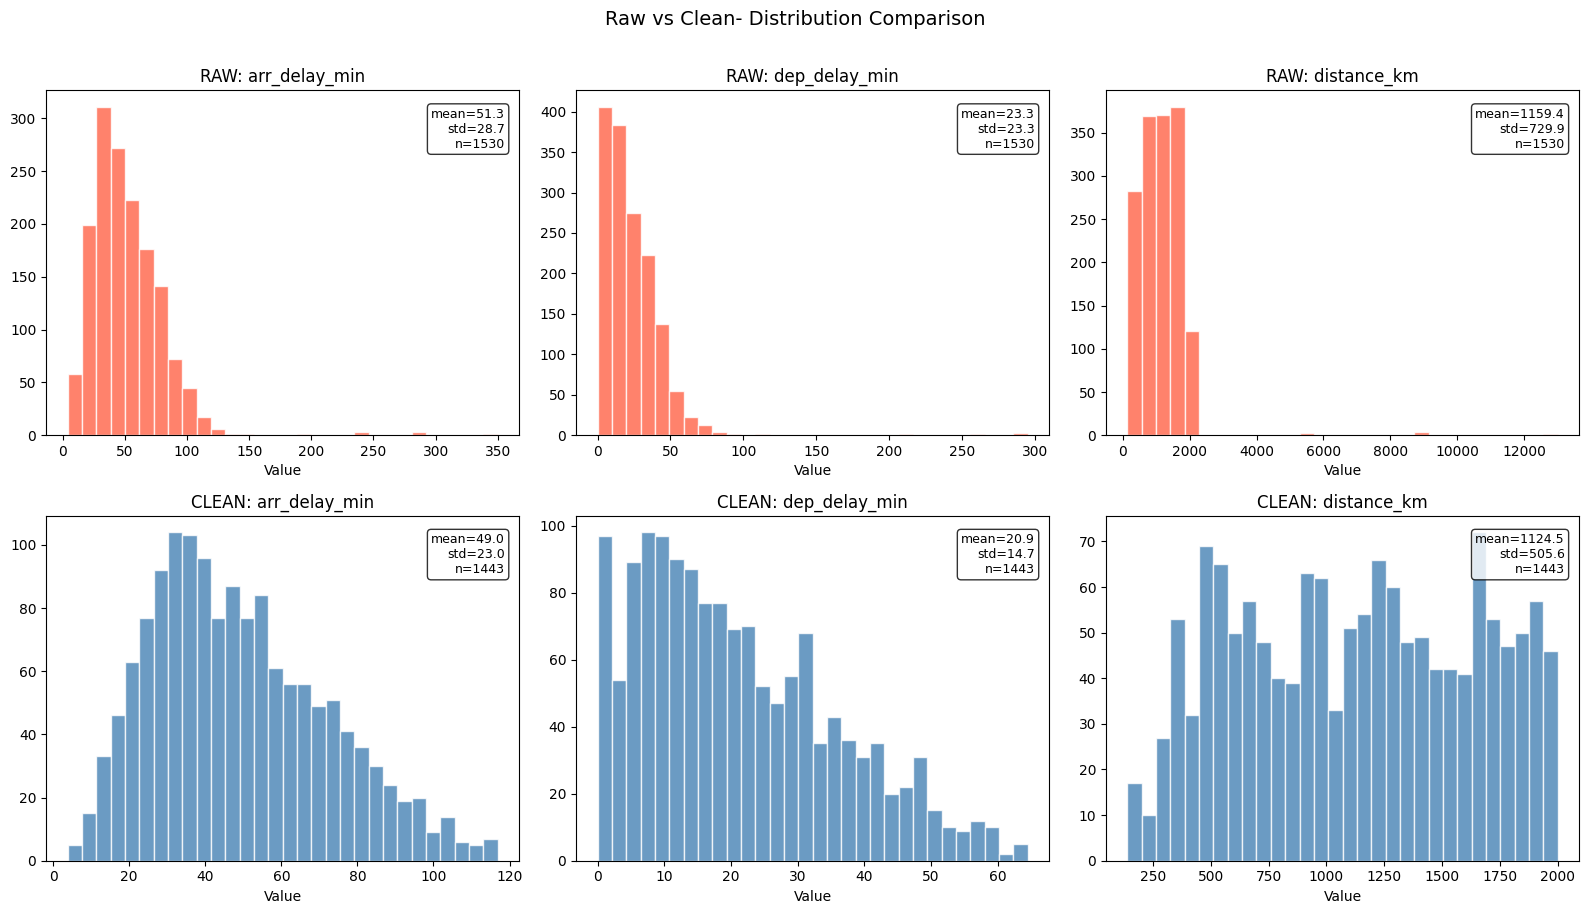

In [82]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

compare_cols = ['arr_delay_min', 'dep_delay_min', 'distance_km']

for col, ax_raw, ax_clean in zip(compare_cols, axes[0], axes[1]):
    raw_data   = df_raw[col].dropna()
    clean_data = df[col]

    ax_raw.hist(raw_data,   bins=30, color='tomato',      edgecolor='white', alpha=0.8)
    ax_raw.set_title(f'RAW: {col}')
    ax_raw.set_xlabel('Value')
    ax_raw.text(0.97, 0.95, f'mean={raw_data.mean():.1f}\nstd={raw_data.std():.1f}\nn={len(raw_data)}',
                transform=ax_raw.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

    ax_clean.hist(clean_data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax_clean.set_title(f'CLEAN: {col}')
    ax_clean.set_xlabel('Value')
    ax_clean.text(0.97, 0.95, f'mean={clean_data.mean():.1f}\nstd={clean_data.std():.1f}\nn={len(clean_data)}',
                  transform=ax_clean.transAxes, ha='right', va='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

plt.suptitle('Raw vs Clean- Distribution Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [83]:
# Summary table: before vs after
print(f'  {"":30} {"RAW":>12}   {"CLEAN":>12}')
print(f'  {"Total rows":<30} {len(df_raw):>12}   {len(df):>12}')
print(f'  {"Missing values":<30} {int(df_raw.isnull().sum().sum()):>12}   {int(df.isnull().sum().sum()):>12}')
print(f'  {"Duplicate rows":<30} {int(df_raw.duplicated().sum()):>12}   {int(df.duplicated().sum()):>12}')
print(f'  {"arr_delay max (min)":<30} {df_raw["arr_delay_min"].max():>12.0f}   {df["arr_delay_min"].max():>12.1f}')
print(f'  {"arr_delay mean (min)":<30} {df_raw["arr_delay_min"].mean():>12.1f}   {df["arr_delay_min"].mean():>12.1f}')
print(f'  {"arr_delay std (min)":<30} {df_raw["arr_delay_min"].std():>12.1f}   {df["arr_delay_min"].std():>12.1f}')
print(f'  {"distance_km max":<30} {df_raw["distance_km"].max():>12.0f}   {df["distance_km"].max():>12.0f}')

                                          RAW          CLEAN
  Total rows                             1530           1443
  Missing values                          528              0
  Duplicate rows                           30              0
  arr_delay max (min)                     350          116.9
  arr_delay mean (min)                   51.3           49.0
  arr_delay std (min)                    28.7           23.0
  distance_km max                       13000           2000


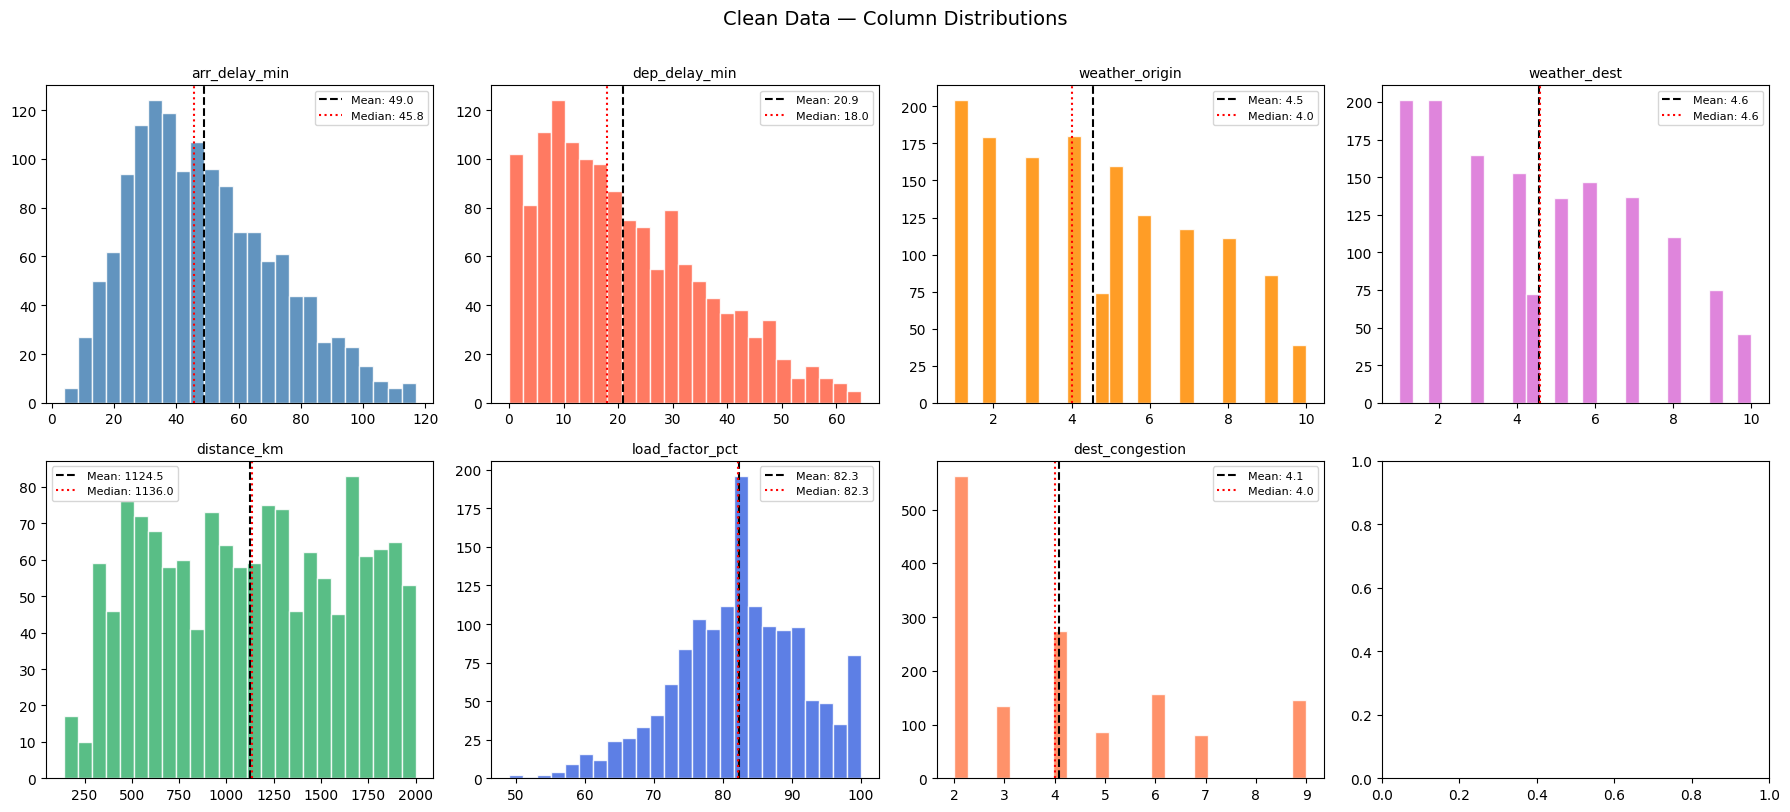

In [84]:
num_cols = ['arr_delay_min','dep_delay_min','weather_origin','weather_dest',
            'distance_km','load_factor_pct','dest_congestion']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
colors = ['steelblue','tomato','darkorange','orchid','mediumseagreen','royalblue','coral','gold']

for ax, col, color in zip(axes.flat, num_cols, colors):
    ax.hist(df[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='black',  linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='red', linestyle=':',  linewidth=1.5,
               label=f'Median: {df[col].median():.1f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Clean Data — Column Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

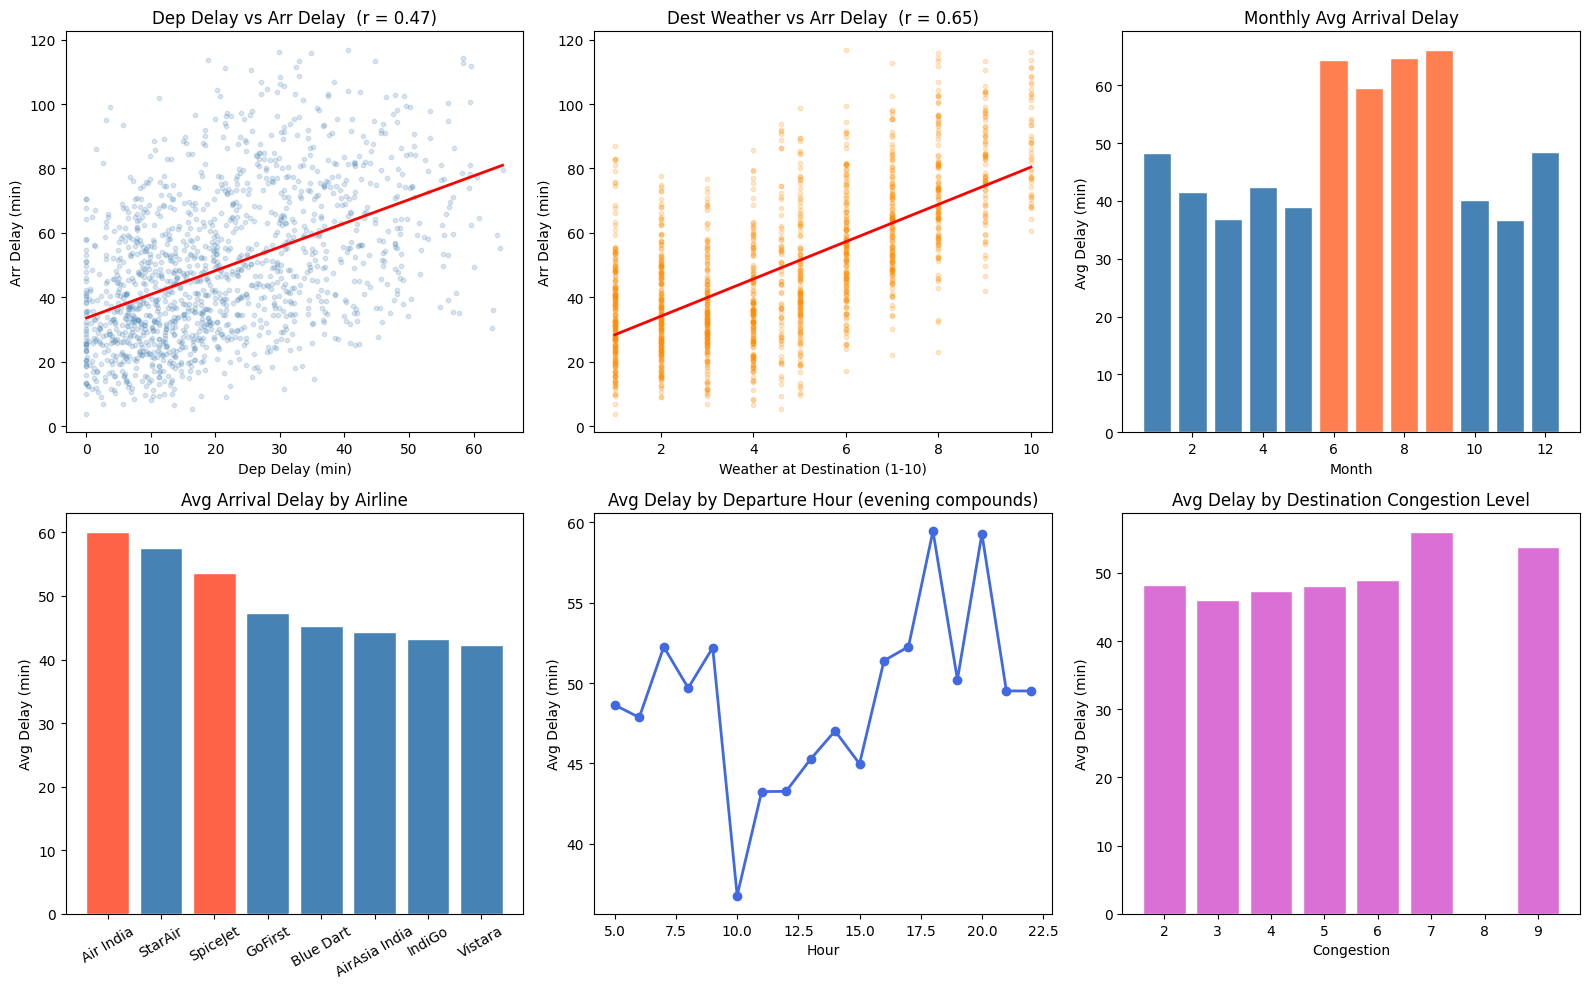

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Dep delay vs Arr delay
axes[0,0].scatter(df['dep_delay_min'], df['arr_delay_min'], alpha=0.2, s=10, color='steelblue')
z = np.polyfit(df['dep_delay_min'], df['arr_delay_min'], 1)
xl = np.linspace(0, df['dep_delay_min'].max(), 100)
axes[0,0].plot(xl, np.poly1d(z)(xl), 'r-', linewidth=2)
r = df['dep_delay_min'].corr(df['arr_delay_min'])
axes[0,0].set_title(f'Dep Delay vs Arr Delay  (r = {r:.2f})')
axes[0,0].set_xlabel('Dep Delay (min)'); axes[0,0].set_ylabel('Arr Delay (min)')

# 2. Weather at dest vs Arr delay
axes[0,1].scatter(df['weather_dest'], df['arr_delay_min'], alpha=0.2, s=10, color='darkorange')
z2 = np.polyfit(df['weather_dest'], df['arr_delay_min'], 1)
xl2 = np.linspace(1, 10, 100)
axes[0,1].plot(xl2, np.poly1d(z2)(xl2), 'r-', linewidth=2)
r2 = df['weather_dest'].corr(df['arr_delay_min'])
axes[0,1].set_title(f'Dest Weather vs Arr Delay  (r = {r2:.2f})')
axes[0,1].set_xlabel('Weather at Destination (1-10)'); axes[0,1].set_ylabel('Arr Delay (min)')

# 3. Monthly avg delay
monthly = df.groupby('month')['arr_delay_min'].mean()
mn = ['J','F','M','A','M','J','J','A','S','O','N','D']
bar_colors = ['coral' if m in [6,7,8,9] else 'steelblue' for m in range(1,13)]
axes[0,2].bar(range(1,13), monthly.values, color=bar_colors, edgecolor='white')
axes[0,2].set_title('Monthly Avg Arrival Delay')
axes[0,2].set_xlabel('Month'); axes[0,2].set_ylabel('Avg Delay (min)')

# 4. Airline comparison
al_avg = df.groupby('airline')['arr_delay_min'].mean().sort_values(ascending=False)
bar_c2 = ['tomato' if a in ['Air India','SpiceJet'] else 'steelblue' for a in al_avg.index]
axes[1,0].bar(al_avg.index, al_avg.values, color=bar_c2, edgecolor='white')
axes[1,0].set_title('Avg Arrival Delay by Airline')
axes[1,0].set_ylabel('Avg Delay (min)')
axes[1,0].tick_params(axis='x', rotation=30)

# 5. Hour of day
hourly = df.groupby('scheduled_dep_hour')['arr_delay_min'].mean()
axes[1,1].plot(hourly.index, hourly.values, marker='o', color='royalblue', linewidth=2)
axes[1,1].set_title('Avg Delay by Departure Hour (evening compounds)')
axes[1,1].set_xlabel('Hour'); axes[1,1].set_ylabel('Avg Delay (min)')

# 6. Dest congestion vs delay
cong = df.groupby('dest_congestion')['arr_delay_min'].mean()
axes[1,2].bar(cong.index, cong.values, color='orchid', edgecolor='white')
axes[1,2].set_title('Avg Delay by Destination Congestion Level')
axes[1,2].set_xlabel('Congestion'); 
axes[1,2].set_ylabel('Avg Delay (min)')

plt.tight_layout()
plt.show()

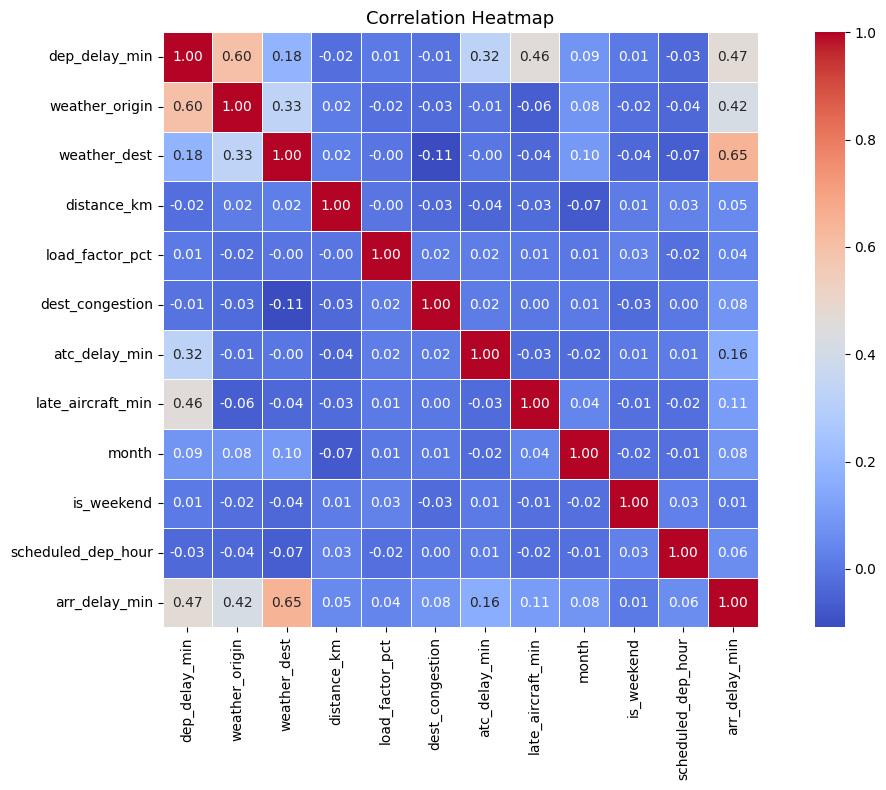

In [86]:
# Correlation heatmap
features = ['dep_delay_min','weather_origin','weather_dest','distance_km',
            'load_factor_pct','dest_congestion','atc_delay_min',
            'late_aircraft_min','month','is_weekend','scheduled_dep_hour']

plt.figure(figsize=(12, 8))
corr_matrix = df[features + ['arr_delay_min']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

In [87]:
print('Feature ranges BEFORE normalisation:')
print(f'  {"Feature":<25} {"Min":>10}  {"Max":>10}  {"Range":>10}')
for f in features:
    mn_v = df[f].min(); mx_v = df[f].max()
    print(f'  {f:<25} {mn_v:>10.1f}  {mx_v:>10.1f}  {mx_v-mn_v:>10.1f}')

Feature ranges BEFORE normalisation:
  Feature                          Min         Max       Range
  dep_delay_min                    0.0        64.5        64.5
  weather_origin                   1.0        10.0         9.0
  weather_dest                     1.0        10.0         9.0
  distance_km                    140.0      2000.0      1860.0
  load_factor_pct                 49.0       100.0        51.0
  dest_congestion                  2.0         9.0         7.0
  atc_delay_min                    0.0        37.3        37.3
  late_aircraft_min                0.0        46.5        46.5
  month                            1.0        12.0        11.0
  is_weekend                       0.0         1.0         1.0
  scheduled_dep_hour               5.0        22.0        17.0


In [88]:
# Apply Min-Max normalisation
X_raw_vals = df[features].copy().reset_index(drop=True)
y          = df['arr_delay_min'].copy().reset_index(drop=True)

scaler   = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw_vals), columns=features)

print('Feature ranges AFTER Min-Max normalisation:')
print(f'  {"Feature":<25} {"Min":>8}  {"Max":>8}')
for f in features:
    print(f'  {f:<25} {X_scaled[f].min():>8.3f}  {X_scaled[f].max():>8.3f}')

Feature ranges AFTER Min-Max normalisation:
  Feature                        Min       Max
  dep_delay_min                0.000     1.000
  weather_origin               0.000     1.000
  weather_dest                 0.000     1.000
  distance_km                  0.000     1.000
  load_factor_pct              0.000     1.000
  dest_congestion              0.000     1.000
  atc_delay_min                0.000     1.000
  late_aircraft_min            0.000     1.000
  month                        0.000     1.000
  is_weekend                   0.000     1.000
  scheduled_dep_hour           0.000     1.000


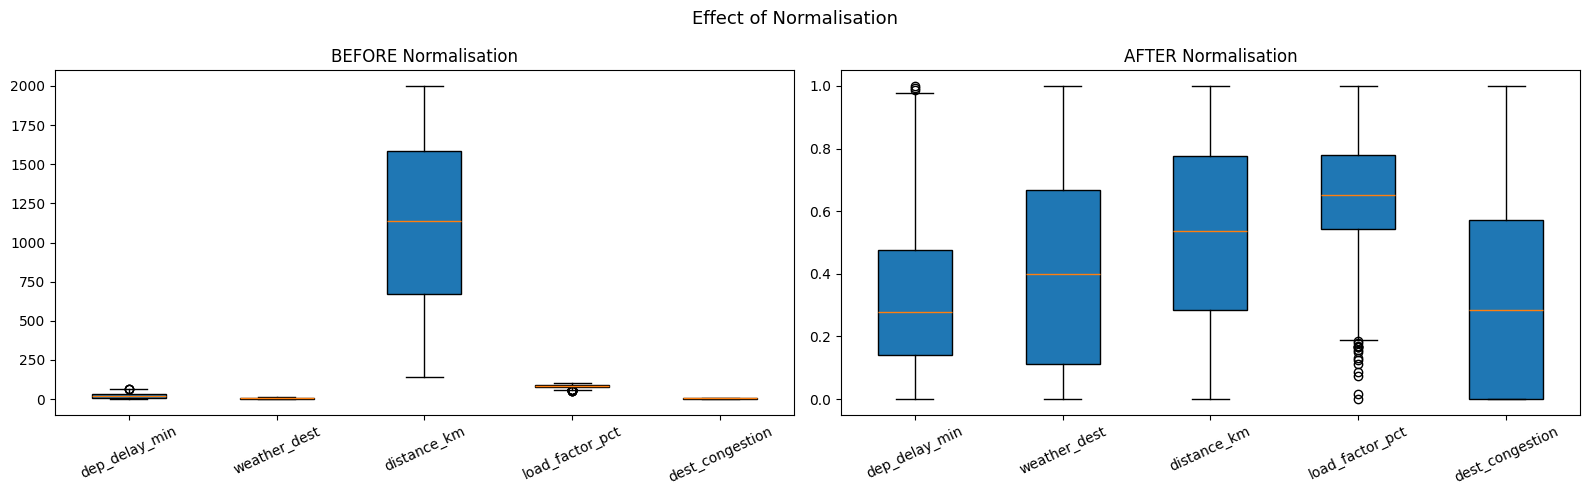

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

show = ['dep_delay_min','weather_dest','distance_km','load_factor_pct','dest_congestion']

axes[0].boxplot([X_raw_vals[c].values for c in show],
                tick_labels=show, patch_artist=True)
axes[0].set_title('BEFORE Normalisation')
axes[0].tick_params(axis='x', rotation=25)

axes[1].boxplot([X_scaled[c].values for c in show],
                tick_labels=show, patch_artist=True)
axes[1].set_title('AFTER Normalisation')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Effect of Normalisation', fontsize=13)
plt.tight_layout()
plt.show()

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 1154
Testing  samples : 289


In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train
lr_model = LinearRegression()
lr_model.fit(X_test, y_test)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_r2   = r2_score(y_test, lr_pred)

print("=== Linear Regression Results ===")
print(f"  MAE  : {lr_mae:.2f} min")
print(f"  RMSE : {lr_rmse:.2f} min")
print(f"  R²   : {lr_r2:.4f}")

=== Linear Regression Results ===
  MAE  : 11.15 min
  RMSE : 14.26 min
  R²   : 0.5973


In [92]:
# ── Overfitting / Underfitting Check: Linear Regression ──────────────────────
from sklearn.metrics import r2_score as _r2

_train_r2 = _r2(y_train, lr_model.predict(X_train))
_test_r2  = _r2(y_test,  lr_model.predict(X_test))
_gap      = _train_r2 - _test_r2



print("=" * 55)
print(f"  Model      : Linear Regression")
print(f"  Train R²   : {_train_r2:.4f}")
print(f"  Test  R²   : {_test_r2:.4f}")
print("=" * 55)


  Model      : Linear Regression
  Train R²   : 0.5637
  Test  R²   : 0.5973


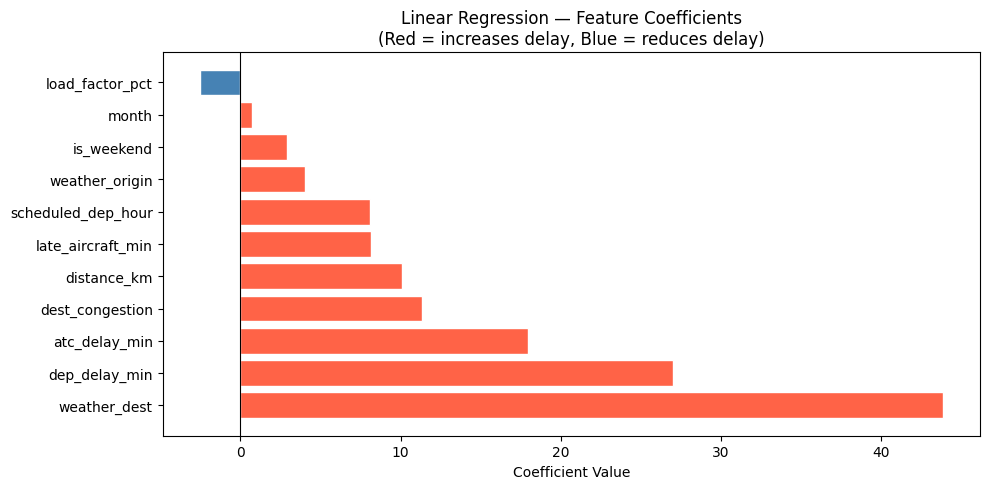

In [93]:
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression — Feature Coefficients\n(Red = increases delay, Blue = reduces delay)')
plt.xlabel('Coefficient Value')
plt.tight_layout(); plt.show()

In [94]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import validation_curve, cross_val_score
import numpy as np


depths = np.arange(2, 25)

train_scores, val_scores = validation_curve(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_train, y_train,
    param_name="max_depth",
    param_range=depths,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

best_depth = depths[np.argmax(val_scores.mean(axis=1))]
print(f"Best max_depth: {best_depth}")


best_leaf, best_cv = None, -np.inf

for leaf in [1, 5, 10, 20, 30]:
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=best_depth,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )
    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring="r2").mean()
    if cv_score > best_cv:
        best_cv, best_leaf = cv_score, leaf



rf_model = RandomForestRegressor(
    n_estimators=200,         # more trees = more stable
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    max_features=0.6,         # each tree sees 60% of features → more diversity
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


rf_pred  = rf_model.predict(X_test)
train_r2 = rf_model.score(X_train, y_train)
test_r2  = r2_score(y_test, rf_pred)
rf_r2   = test_r2 
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred)**0.5

print("\n=======================================================")
print(f"  Model      : Random Forest")
print(f"  Train R²   : {train_r2:.4f}")
print(f"  Test  R²   : {test_r2:.4f}")
print(f"  MAE        : {mean_absolute_error(y_test, rf_pred):.2f} min")
print(f"  RMSE       : {mean_squared_error(y_test, rf_pred)**0.5:.2f} min")
print("=======================================================")

Best max_depth: 7

  Model      : Random Forest
  Train R²   : 0.7123
  Test  R²   : 0.6009
  MAE        : 11.23 min
  RMSE       : 14.20 min


In [95]:
# ── Overfitting / Underfitting Check: Random Forest ──────────────────────
from sklearn.metrics import r2_score as _r2

_train_r2 = _r2(y_train, rf_model.predict(X_train))
_test_r2  = _r2(y_test,  rf_model.predict(X_test))
_gap      = _train_r2 - _test_r2



print("=" * 55)
print(f"  Model      : Random Forest")
print(f"  Train R²   : {_train_r2:.4f}")
print(f"  Test  R²   : {_test_r2:.4f}")
print("=" * 55)


  Model      : Random Forest
  Train R²   : 0.7123
  Test  R²   : 0.6009


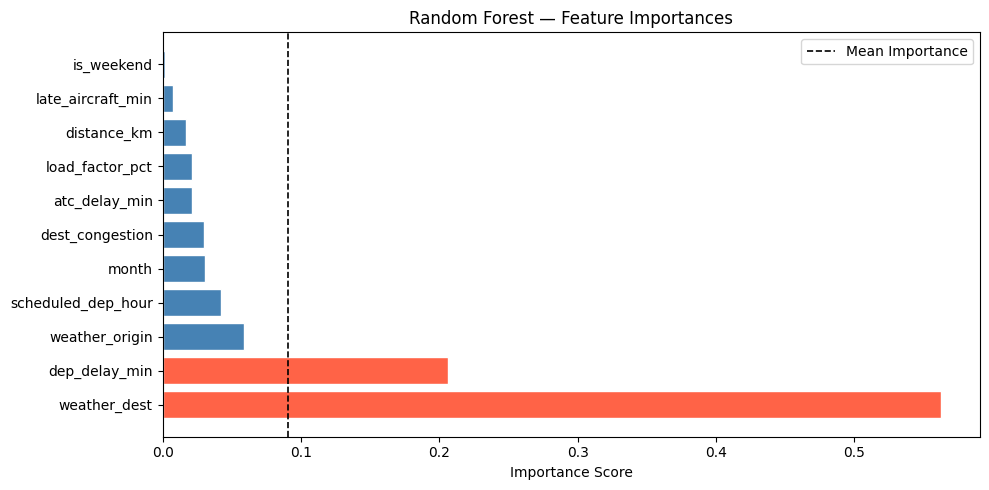

In [96]:
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['tomato' if v > feat_imp.mean() else 'steelblue' for v in feat_imp.values]
plt.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
plt.axvline(feat_imp.mean(), color='black', linestyle='--', linewidth=1.2, label='Mean Importance')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()


In [97]:
from sklearn.neighbors import KNeighborsRegressor

# Train
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predict
knn_pred = knn_model.predict(X_test)

# Evaluate
knn_mae  = mean_absolute_error(y_test, knn_pred)
knn_rmse = mean_squared_error(y_test, knn_pred) ** 0.5
knn_r2   = r2_score(y_test, knn_pred)

print("=== KNN Regressor Results (k=5) ===")
print(f"  MAE  : {knn_mae:.2f} min")
print(f"  RMSE : {knn_rmse:.2f} min")
print(f"  R²   : {knn_r2:.4f}")

=== KNN Regressor Results (k=5) ===
  MAE  : 13.75 min
  RMSE : 17.09 min
  R²   : 0.4217


Best K : 24  (RMSE = 15.63)


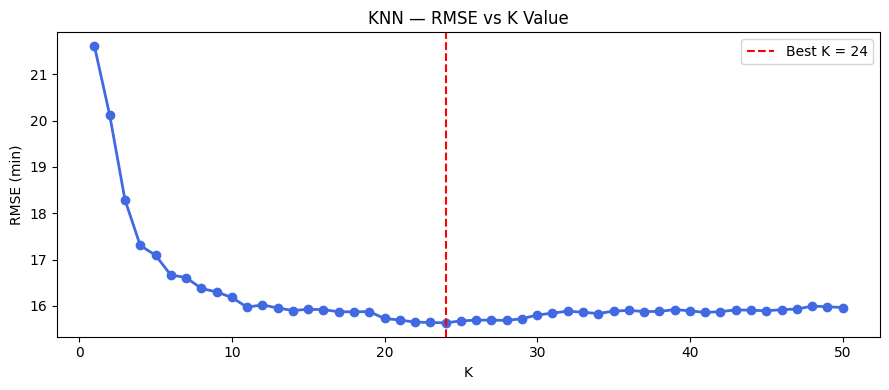

In [98]:
k_values = range(1, 51)
k_rmse   = []

for k in k_values:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    k_rmse.append(mean_squared_error(y_test, pred) ** 0.5)

best_k = k_values[k_rmse.index(min(k_rmse))]
print(f"Best K : {best_k}  (RMSE = {min(k_rmse):.2f})")

plt.figure(figsize=(9, 4))
plt.plot(k_values, k_rmse, marker='o', color='royalblue', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.title('KNN — RMSE vs K Value')
plt.xlabel('K'); plt.ylabel('RMSE (min)')
plt.legend(); plt.tight_layout(); plt.show()

In [99]:
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
knn_best_pred = knn_best.predict(X_test)

knn_mae  = mean_absolute_error(y_test, knn_best_pred)
knn_rmse = mean_squared_error(y_test, knn_best_pred) ** 0.5
knn_r2   = r2_score(y_test, knn_best_pred)

print(f"=== KNN Regressor Results (k={best_k}) ===")
print(f"  MAE  : {knn_mae:.2f} min")
print(f"  RMSE : {knn_rmse:.2f} min")
print(f"  R²   : {knn_r2:.4f}")

=== KNN Regressor Results (k=24) ===
  MAE  : 12.38 min
  RMSE : 15.63 min
  R²   : 0.5164


In [100]:
# ── Overfitting / Underfitting Check: KNN ──────────────────────
from sklearn.metrics import r2_score as _r2

_train_r2 = _r2(y_train, knn_best.predict(X_train))
_test_r2  = _r2(y_test,  knn_best.predict(X_test))
_gap      = _train_r2 - _test_r2

print("=" * 55)
print(f"  Model      : KNN")
print(f"  Train R²   : {_train_r2:.4f}")
print(f"  Test  R²   : {_test_r2:.4f}")
print("=" * 55)


  Model      : KNN
  Train R²   : 0.5649
  Test  R²   : 0.5164


In [101]:
from sklearn.neighbors import KNeighborsRegressor

rf_importances = rf_model.feature_importances_
X_train_w = X_train.values * rf_importances
X_test_w  = X_test.values  * rf_importances

wknn_model = KNeighborsRegressor(n_neighbors=5)
wknn_model.fit(X_train_w, y_train)
wknn_pred = wknn_model.predict(X_test_w)

wknn_mae  = mean_absolute_error(y_test, wknn_pred)
wknn_rmse = mean_squared_error(y_test, wknn_pred) ** 0.5
wknn_r2   = r2_score(y_test, wknn_pred)

print("=== Weighted KNN Results (k=5) ===")
print(f"  MAE  : {wknn_mae:.2f} min")
print(f"  RMSE : {wknn_rmse:.2f} min")
print(f"  R\u00b2   : {wknn_r2:.4f}")

=== Weighted KNN Results (k=5) ===
  MAE  : 12.12 min
  RMSE : 15.16 min
  R²   : 0.5453


Best K : 16  (RMSE = 14.56)


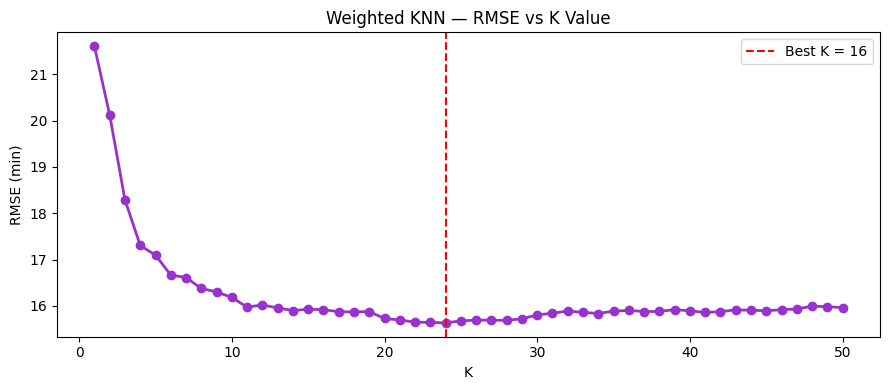

In [102]:
wk_values = range(1, 51)
wk_rmse   = []

for k in wk_values:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train_w, y_train)
    pred = m.predict(X_test_w)
    wk_rmse.append(mean_squared_error(y_test, pred) ** 0.5)

best_wk = wk_values[wk_rmse.index(min(wk_rmse))]
print(f"Best K : {best_wk}  (RMSE = {min(wk_rmse):.2f})")

plt.figure(figsize=(9, 4))
plt.plot(k_values, k_rmse, marker='o', color='darkorchid', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_wk}')
plt.title('Weighted KNN — RMSE vs K Value')
plt.xlabel('K')
plt.ylabel('RMSE (min)')
plt.legend()
plt.tight_layout()
plt.show()

In [103]:
wknn_best = KNeighborsRegressor(n_neighbors=best_wk)
wknn_best.fit(X_train_w, y_train)
wknn_best_pred = wknn_best.predict(X_test_w)

wknn_mae  = mean_absolute_error(y_test, wknn_best_pred)
wknn_rmse = mean_squared_error(y_test, wknn_best_pred) ** 0.5
wknn_r2   = r2_score(y_test, wknn_best_pred)

print(f"=== Weighted KNN Results (k={best_wk}) ===")
print(f"  MAE  : {wknn_mae:.2f} min")
print(f"  RMSE : {wknn_rmse:.2f} min")
print(f"  R\u00b2   : {wknn_r2:.4f}")

=== Weighted KNN Results (k=16) ===
  MAE  : 11.37 min
  RMSE : 14.56 min
  R²   : 0.5804


In [104]:
# ── Overfitting / Underfitting Check: Weighted KNN ──────────────────────
from sklearn.metrics import r2_score as _r2

_train_r2 = _r2(y_train, wknn_best.predict(X_train_w))
_test_r2  = _r2(y_test,  wknn_best.predict(X_test_w))
_gap      = _train_r2 - _test_r2



print("=" * 55)
print(f"  Model      : Weighted KNN")
print(f"  Train R²   : {_train_r2:.4f}")
print(f"  Test  R²   : {_test_r2:.4f}")
print("=" * 55)


  Model      : Weighted KNN
  Train R²   : 0.6236
  Test  R²   : 0.5804


In [105]:
from sklearn.linear_model import Lasso, LassoCV

# Find best alpha via cross-validation
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso_cv.fit(X_train, y_train)
best_alpha_lasso = lasso_cv.alpha_
print(f"Best Lasso alpha (CV): {best_alpha_lasso:.6f}")

# Train with best alpha
lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=5000, random_state=42)
lasso_model.fit(X_train, y_train)

# Predict
lasso_pred = lasso_model.predict(X_test)

# Evaluate
lasso_mae  = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = mean_squared_error(y_test, lasso_pred) ** 0.5
lasso_r2   = r2_score(y_test, lasso_pred)

print("\n=== Lasso Regression Results ===")
print(f"  MAE  : {lasso_mae:.2f} min")
print(f"  RMSE : {lasso_rmse:.2f} min")
print(f"  R\u00b2   : {lasso_r2:.4f}")

Best Lasso alpha (CV): 0.012472

=== Lasso Regression Results ===
  MAE  : 11.39 min
  RMSE : 14.68 min
  R²   : 0.5736


In [106]:
# ── Overfitting / Underfitting Check: Lasso ──────────────────────
from sklearn.metrics import r2_score as _r2

_train_r2 = _r2(y_train, lasso_model.predict(X_train))
_test_r2  = _r2(y_test,  lasso_model.predict(X_test))
_gap      = _train_r2 - _test_r2


print("=" * 55)
print(f"  Model      : Lasso")
print(f"  Train R²   : {_train_r2:.4f}")
print(f"  Test  R²   : {_test_r2:.4f}")
print("=" * 55)


  Model      : Lasso
  Train R²   : 0.5916
  Test  R²   : 0.5736


In [107]:
from sklearn.linear_model import Ridge, RidgeCV

# Find best alpha via cross-validation
alphas = [0.01, 0.1, 1, 10, 100, 500, 1000]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)
best_alpha_ridge = ridge_cv.alpha_
print(f"Best Ridge alpha (CV): {best_alpha_ridge}")

# Train with best alpha
ridge_model = Ridge(alpha=best_alpha_ridge)
ridge_model.fit(X_train, y_train)

# Predict
ridge_pred = ridge_model.predict(X_test)

# Evaluate
ridge_mae  = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = mean_squared_error(y_test, ridge_pred) ** 0.5
ridge_r2   = r2_score(y_test, ridge_pred)

print("\n=== Ridge Regression Results ===")
print(f"  MAE  : {ridge_mae:.2f} min")
print(f"  RMSE : {ridge_rmse:.2f} min")
print(f"  R\u00b2   : {ridge_r2:.4f}")


Best Ridge alpha (CV): 1.0

=== Ridge Regression Results ===
  MAE  : 11.37 min
  RMSE : 14.66 min
  R²   : 0.5746


In [108]:
# ── Overfitting / Underfitting Check: Ridge ──────────────────────
from sklearn.metrics import r2_score as _r2

_train_r2 = _r2(y_train, ridge_model.predict(X_train))
_test_r2  = _r2(y_test,  ridge_model.predict(X_test))
_gap      = _train_r2 - _test_r2


print("=" * 55)
print(f"  Model      : Ridge")
print(f"  Train R²   : {_train_r2:.4f}")
print(f"  Test  R²   : {_test_r2:.4f}")
print("=" * 55)


  Model      : Ridge
  Train R²   : 0.5915
  Test  R²   : 0.5746


In [109]:
from sklearn.linear_model import ElasticNet, ElasticNetCV

# Find best params via cross-validation
enr_cv = ElasticNetCV(cv=5, random_state=42, max_iter=5000,
                      l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95])
enr_cv.fit(X_train, y_train)
best_alpha_enr  = enr_cv.alpha_
best_l1_ratio   = enr_cv.l1_ratio_
print(f"Best ElasticNet alpha   (CV): {best_alpha_enr:.6f}")
print(f"Best ElasticNet l1_ratio(CV): {best_l1_ratio:.2f}")

# Train with best params
enr_model = ElasticNet(alpha=best_alpha_enr, l1_ratio=best_l1_ratio,
                       max_iter=5000, random_state=42)
enr_model.fit(X_train, y_train)

# Predict
enr_pred = enr_model.predict(X_test)

# Evaluate
enr_mae  = mean_absolute_error(y_test, enr_pred)
enr_rmse = mean_squared_error(y_test, enr_pred) ** 0.5
enr_r2   = r2_score(y_test, enr_pred)

print("\n=== Elastic Net Regression Results ===")
print(f"  MAE  : {enr_mae:.2f} min")
print(f"  RMSE : {enr_rmse:.2f} min")
print(f"  R\u00b2   : {enr_r2:.4f}")


Best ElasticNet alpha   (CV): 0.005683
Best ElasticNet l1_ratio(CV): 0.95

=== Elastic Net Regression Results ===
  MAE  : 11.38 min
  RMSE : 14.67 min
  R²   : 0.5739


In [110]:
# ── Overfitting / Underfitting Check: Elastic Net ──────────────────────
from sklearn.metrics import r2_score as _r2

_train_r2 = _r2(y_train, enr_model.predict(X_train))
_test_r2  = _r2(y_test,  enr_model.predict(X_test))
_gap      = _train_r2 - _test_r2

print("=" * 55)
print(f"  Model      : Elastic Net")
print(f"  Train R²   : {_train_r2:.4f}")
print(f"  Test  R²   : {_test_r2:.4f}")
print("=" * 55)


  Model      : Elastic Net
  Train R²   : 0.5916
  Test  R²   : 0.5739


In [111]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        f'KNN (k={best_k})',
        f'Weighted KNN (k={best_wk})',
        'Random Forest',
        f'Lasso (\u03b1={best_alpha_lasso:.4f})',
        f'Ridge (\u03b1={best_alpha_ridge})',
        f'Elastic Net (\u03b1={best_alpha_enr:.4f}, l1={best_l1_ratio:.2f})'
    ],
    'MAE' : [lr_mae,  knn_mae, wknn_mae,  rf_mae,  lasso_mae,  ridge_mae,  enr_mae],
    'RMSE': [lr_rmse, knn_rmse, wknn_rmse, rf_rmse, lasso_rmse, ridge_rmse, enr_rmse],
    'R\u00b2'  : [lr_r2,   knn_r2, wknn_r2,   rf_r2,   lasso_r2,   ridge_r2,   enr_r2]
}).sort_values('R\u00b2', ascending=False).reset_index(drop=True)

print("=" * 75)
print("                               MODEL COMPARISON")
print("=" * 75)
print(comparison.to_string(index=False))
print("=" * 75)
winner = comparison.iloc[0]['Model']
print(f"  Best model by R\u00b2 : {winner}")
print("=" * 75)


                               MODEL COMPARISON
                          Model       MAE      RMSE       R²
                  Random Forest 11.231381 14.199597 0.600914
              Linear Regression 11.146483 14.264170 0.597276
            Weighted KNN (k=16) 11.374676 14.560195 0.580387
                  Ridge (α=1.0) 11.374984 14.659992 0.574615
Elastic Net (α=0.0057, l1=0.95) 11.380961 14.671966 0.573920
               Lasso (α=0.0125) 11.389656 14.677992 0.573570
                     KNN (k=24) 12.384011 15.631647 0.516358
  Best model by R² : Random Forest


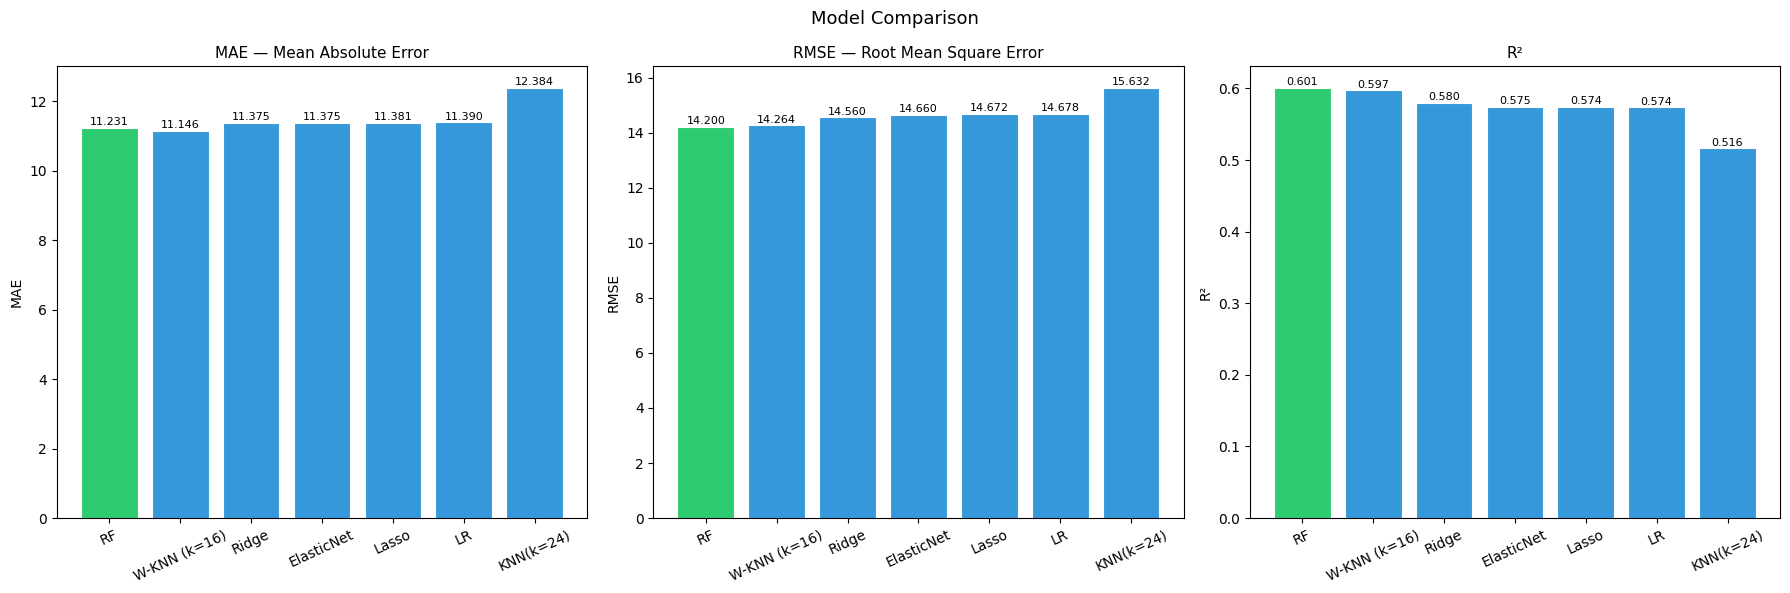

In [112]:
# Bar chart comparison — MAE, RMSE, R²
model_names = comparison['Model'].tolist()
short_names = ['RF', f'W-KNN (k={best_wk})', 'Ridge', 'ElasticNet', 'Lasso', 'LR', f'KNN(k={best_k})']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(comparison))]  

for ax, metric, label in zip(axes, ['MAE', 'RMSE', 'R\u00b2'],
                               ['MAE — Mean Absolute Error',
                                'RMSE — Root Mean Square Error',
                                'R\u00b2']):
    bars = ax.bar(short_names, comparison[metric], color=palette, edgecolor='white', linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002*bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()


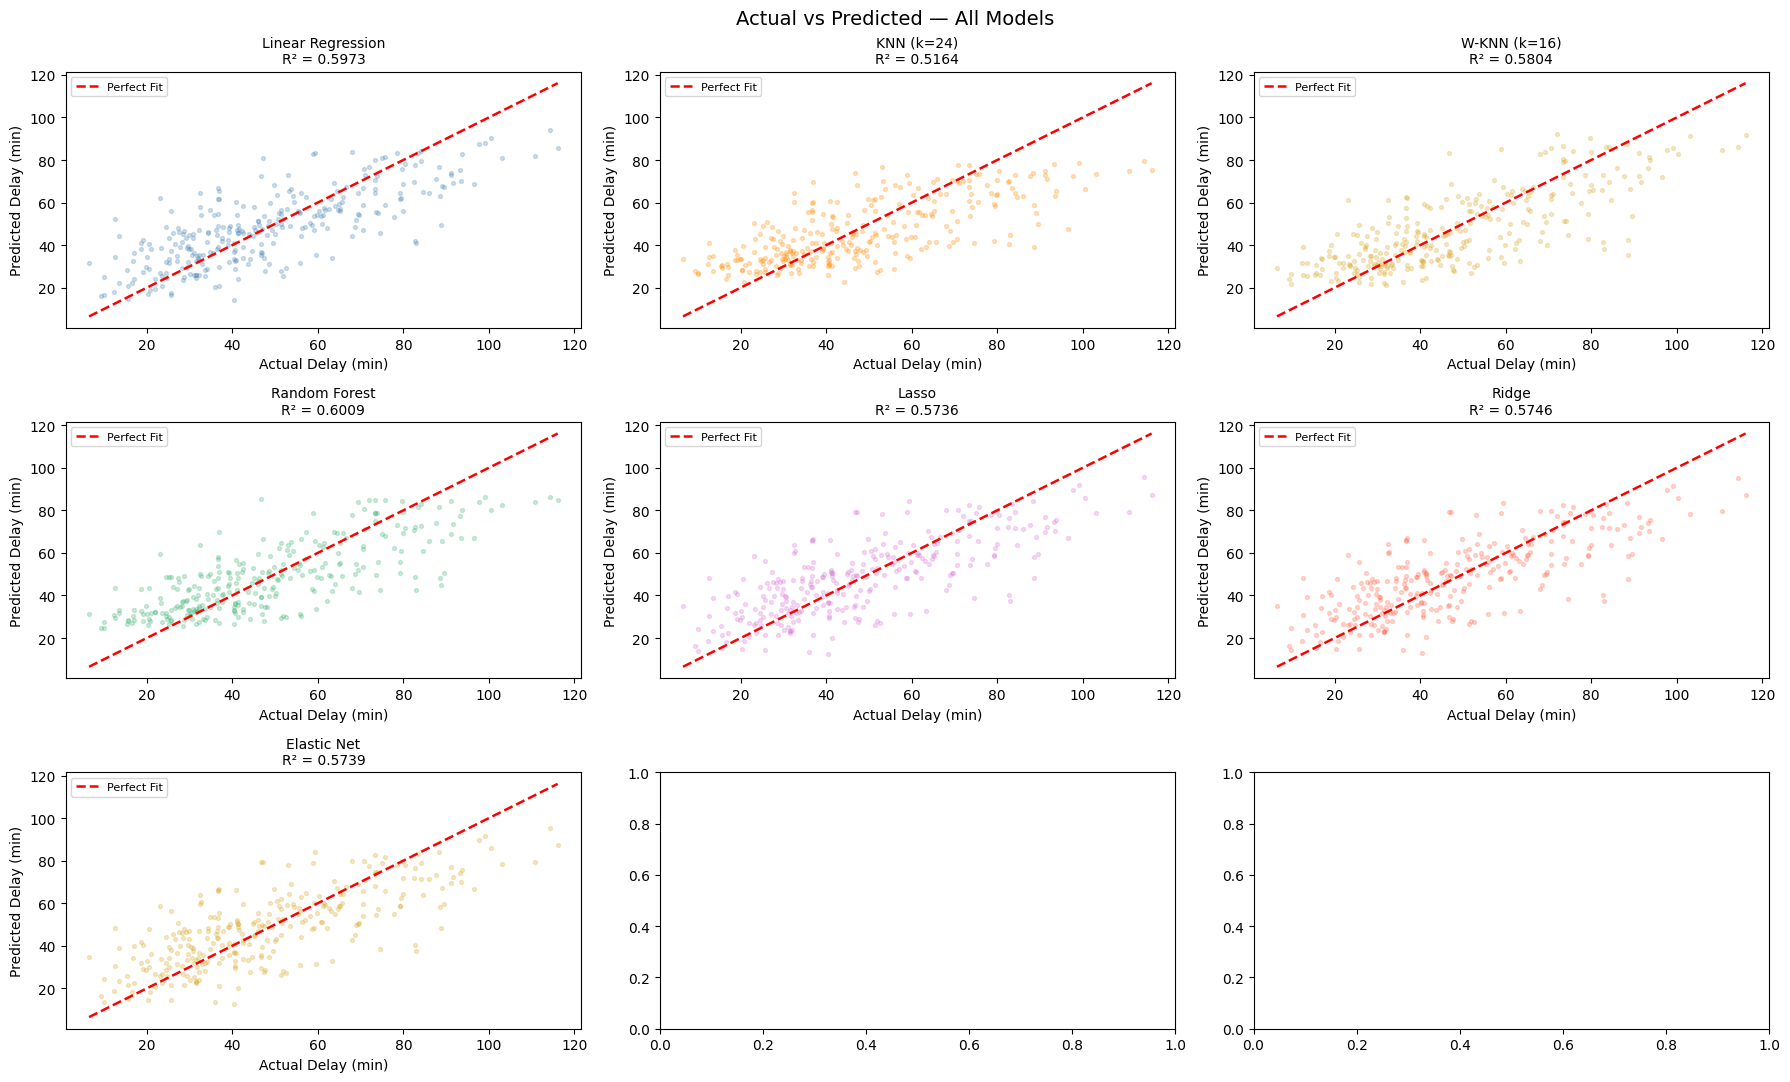

In [113]:
all_preds  = [lr_pred, knn_best_pred, wknn_best_pred, rf_pred, lasso_pred, ridge_pred, enr_pred]
all_names  = ['Linear Regression', f'KNN (k={best_k})', f'W-KNN (k={best_wk})' , 'Random Forest',
               f'Lasso', f'Ridge', 'Elastic Net']
all_colors = ['steelblue','darkorange', 'goldenrod', 'mediumseagreen','orchid','tomato','goldenrod']

fig, axes = plt.subplots(3, 3, figsize=(18, 11))

for ax, name, pred, color in zip(axes.flat, all_names, all_preds, all_colors):
    ax.scatter(y_test, pred, alpha=0.25, s=8, color=color)
    mn = min(y_test.min(), pred.min())
    mx = max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.8, label='Perfect Fit')
    r2 = r2_score(y_test, pred)
    ax.set_title(f'{name}\nR\u00b2 = {r2:.4f}', fontsize=10)
    ax.set_xlabel('Actual Delay (min)')
    ax.set_ylabel('Predicted Delay (min)')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — All Models', fontsize=14)
plt.tight_layout()
plt.show()


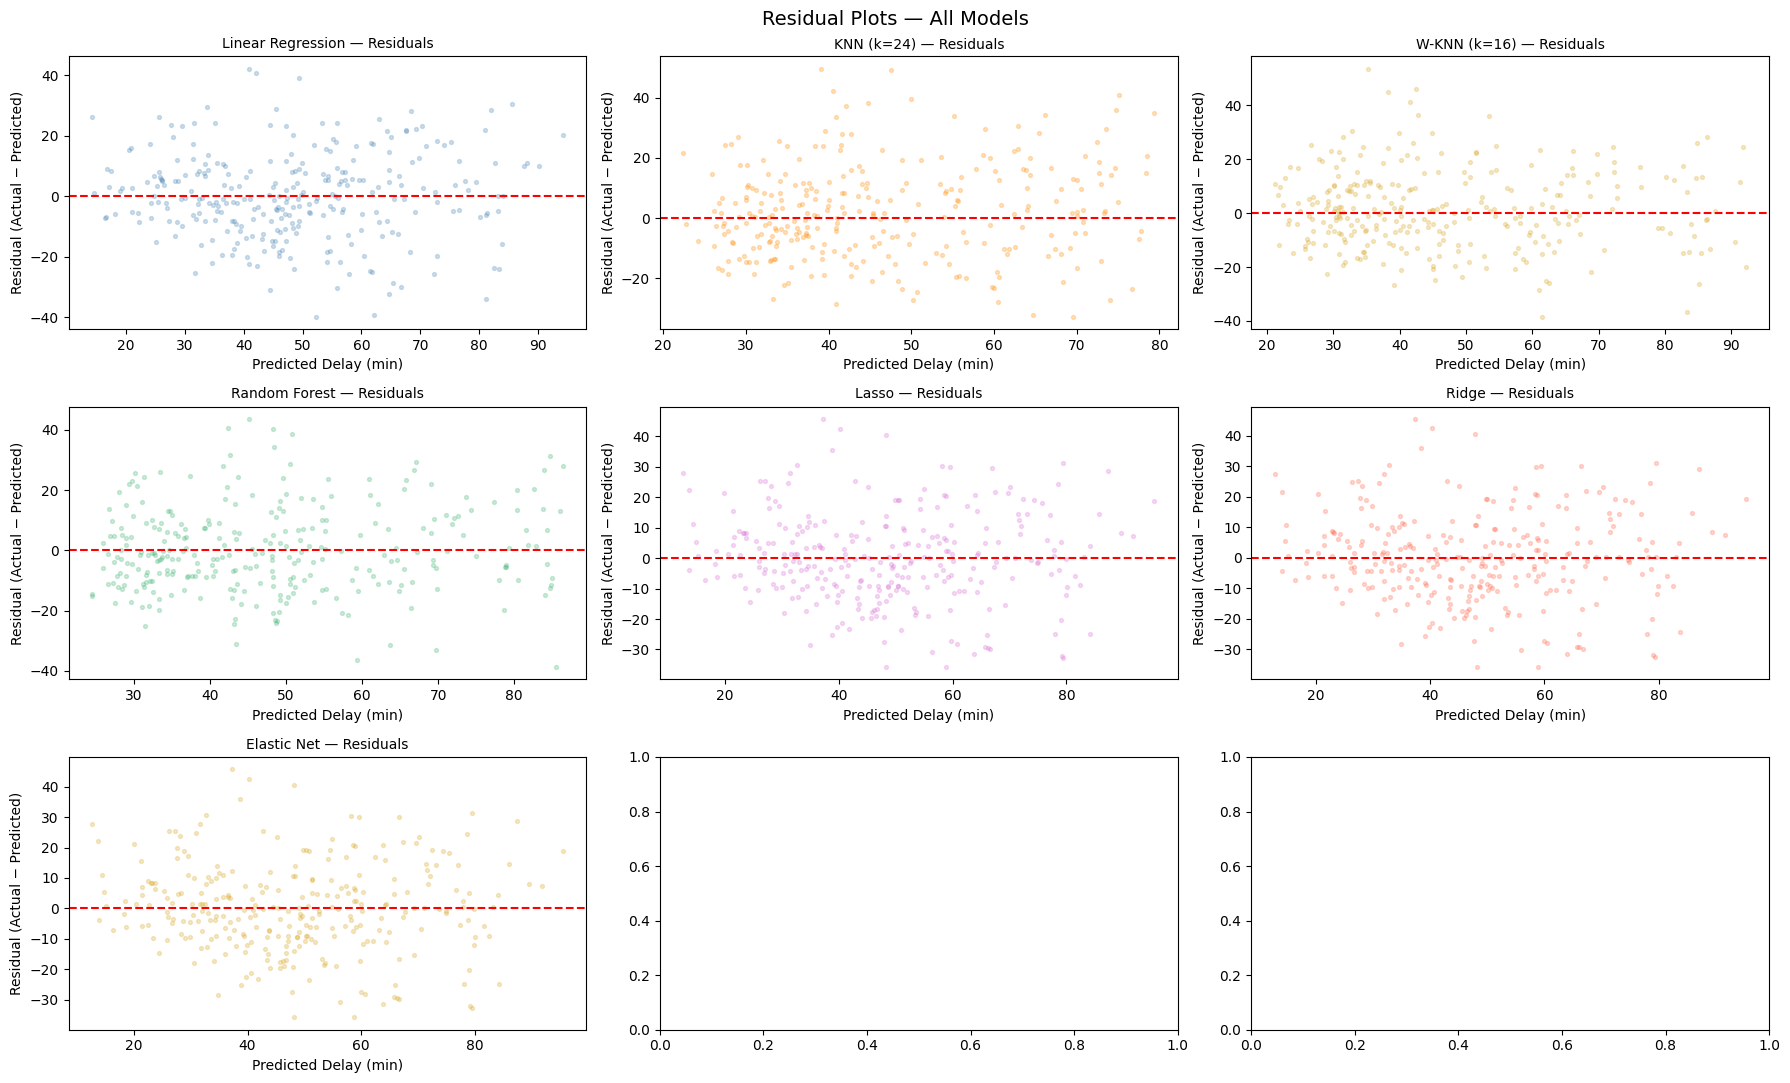

In [114]:
fig, axes = plt.subplots(3, 3, figsize=(18, 11))

for ax, name, pred, color in zip(axes.flat, all_names, all_preds, all_colors):
    residuals = y_test.values - pred
    ax.scatter(pred, residuals, alpha=0.25, s=8, color=color)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'{name} — Residuals', fontsize=10)
    ax.set_xlabel('Predicted Delay (min)')
    ax.set_ylabel('Residual (Actual − Predicted)')

plt.suptitle('Residual Plots — All Models', fontsize=14)
plt.tight_layout()
plt.show()


In [115]:
print("=" * 75)
print("                     FINAL RANKED MODEL SUMMARY")
print("=" * 75)
print(f"{'Rank':<6}{'Model':<45}{'MAE':>8}  {'RMSE':>8}  {'R\u00b2':>8}")
print("-" * 75)
for rank, row in comparison.iterrows():
    print(f"{rank+1:<6}{row['Model']:<45}{row['MAE']:>8.2f}  {row['RMSE']:>8.2f}  {row['R\u00b2']:>8.4f}")
print("=" * 75)
print(f"  \u2605 Best model by R\u00b2 : {comparison.iloc[0]['Model']}")
print("=" * 75)


                     FINAL RANKED MODEL SUMMARY
Rank  Model                                             MAE      RMSE        R²
---------------------------------------------------------------------------
1     Random Forest                                   11.23     14.20    0.6009
2     Linear Regression                               11.15     14.26    0.5973
3     Weighted KNN (k=16)                             11.37     14.56    0.5804
4     Ridge (α=1.0)                                   11.37     14.66    0.5746
5     Elastic Net (α=0.0057, l1=0.95)                 11.38     14.67    0.5739
6     Lasso (α=0.0125)                                11.39     14.68    0.5736
7     KNN (k=24)                                      12.38     15.63    0.5164
  ★ Best model by R² : Random Forest
